In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage
import statsmodels.api as sm
import rasterio
import PIL.Image
from tqdm import tqdm

In [2]:
DIRECTORY = pathlib.Path("~/storage/data/oaec-found-gully").expanduser()

In [3]:
PIL.Image.MAX_IMAGE_PIXELS = None  # I know my images are large; they're not DoS attacks...

In [4]:
names = {
    "pepperwood": "Big Pepperwood Creek",
    "dutch": "Dutch Bill Creek",
    "flat": "Flat Ridge Creek Buckeye",
    "kolmer": "Kolmer Gulch",
    "drylow": "Lower Dry Creek Lower",
    "dry": "Lower Dry Creek",
    "salmon": "Lower Salmon Creek",
    "tombs": "Tombs Creek",
    "sulphur": "Upper Big Sulphur Creek",
}

truth = []
metrics = {
    "min15": [],
    "max15": [],
    "low15": [],
    "highlow15": [],
    "min5": [],
    "max5": [],
    "low5": [],
    "highlow5": [],
}

for name in tqdm(names):
    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
        mask = np.asarray(file)[:, :, 1] < 128

    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
        gully = np.asarray(file)[:, :, 1] > 128

    for metric in metrics:
        with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
            data = file.read(1)
        np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
        metrics[metric].append(data[mask])
        del data

    truth.append(gully[mask])
    del mask
    del gully

100%|█████████████████████████████████████████████████████████████████| 9/9 [01:29<00:00,  9.99s/it]


In [5]:
slices = []
start = 0
for name, array in zip(names, truth):
    stop = start + len(array)
    slices.append(slice(start, stop))
    start = stop

alltruth = np.concatenate(truth)
allmetrics = {metric: np.concatenate(arrays) for metric, arrays in metrics.items()}

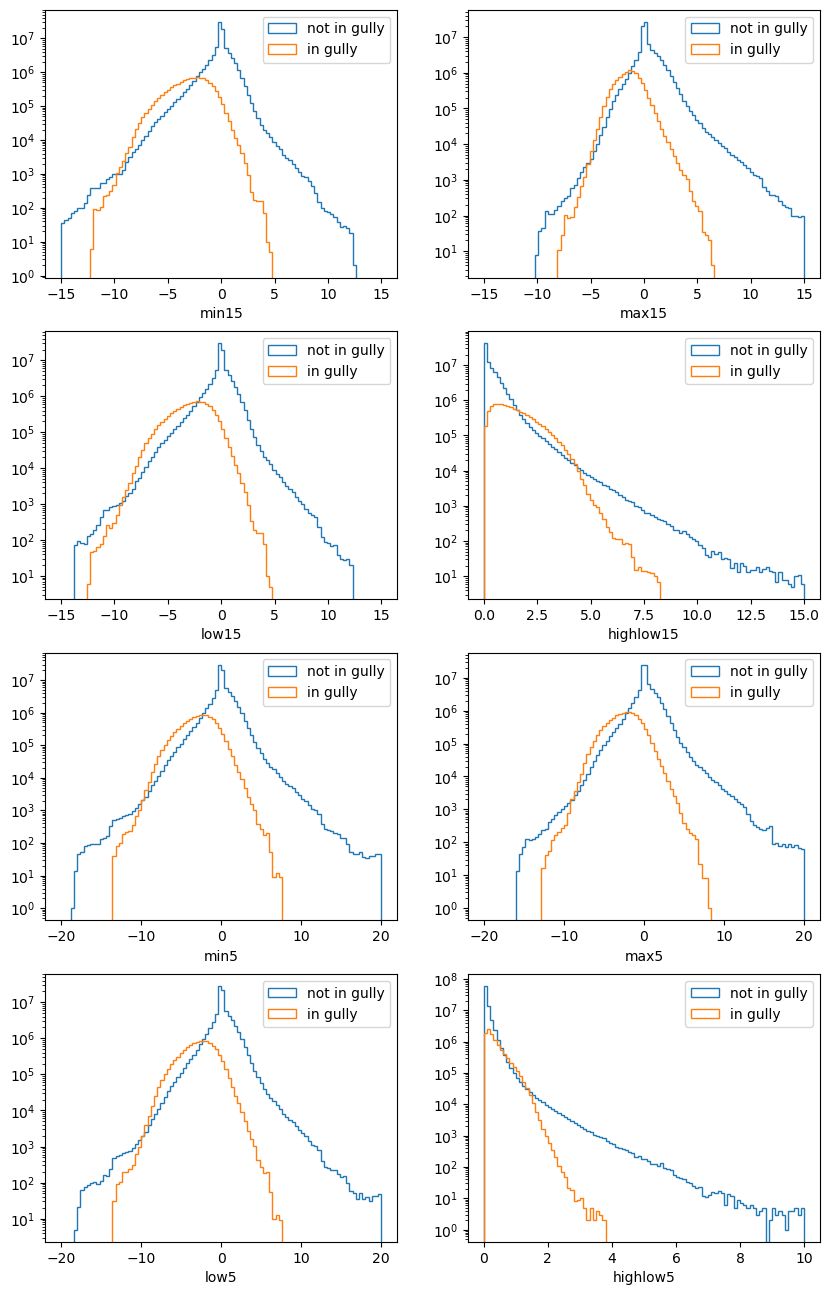

In [6]:
fig, axs = plt.subplots(4, 2, figsize=(10, 16))

ranges = {
    "min15": (-15, 15),
    "max15": (-15, 15),
    "low15": (-15, 15),
    "highlow15": (0, 15),
    "min5": (-20, 20),
    "max5": (-20, 20),
    "low5": (-20, 20),
    "highlow5": (0, 10),
}

for ax, metric in zip(axs.flatten(), metrics):
    ax.hist(allmetrics[metric][~alltruth], bins=100, range=ranges[metric], histtype="step", label="not in gully")
    ax.hist(allmetrics[metric][alltruth], bins=100, range=ranges[metric], histtype="step", label="in gully")

    ax.legend()
    
    ax.set_yscale("log")
    ax.set_xlabel(metric)

None

In [7]:
del truth
del metrics

features = [
    "min15",
    "max15",
    "low15",
    "highlow15",
    "min5",
    "max5",
    "low5",
    "highlow5",
    "low15 * highlow15",
    "low15 * highlow5",
    "low5 * highlow15",
    "low5 * highlow5",
]

X = np.stack([
    allmetrics["min15"],
    allmetrics["max15"],
    allmetrics["low15"],
    allmetrics["highlow15"],
    allmetrics["min5"],
    allmetrics["max5"],
    allmetrics["low5"],
    allmetrics["highlow5"],
    allmetrics["low15"] * allmetrics["highlow15"],
    allmetrics["low15"] * allmetrics["highlow5"],
    allmetrics["low5"] * allmetrics["highlow15"],
    allmetrics["low5"] * allmetrics["highlow5"],
]).T
Y = alltruth

del allmetrics
del alltruth

In [8]:
fit = sm.Logit(Y, sm.add_constant(X)).fit()

Optimization terminated successfully.
         Current function value: 0.170158
         Iterations 8


In [9]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:             93752708
Model:                          Logit   Df Residuals:                 93752695
Method:                           MLE   Df Model:                           12
Date:                Tue, 07 Oct 2025   Pseudo R-squ.:                  0.5000
Time:                        16:50:58   Log-Likelihood:            -1.5953e+07
converged:                       True   LL-Null:                   -3.1904e+07
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6083      0.001  -4138.442      0.000      -4.610      -4.606
x1            -2.5543      0.006   -452.825      0.000      -2.565      -2.543
x2            -1.4621      0.007   -210.713      0.000      -1.476      -1.448
x3            -1.0226      0.007   -147.665      0.000      -1.036      -1.009
x4             2.1824      0.007    330.303      0.000       2.169       2.195
x5             0.0803      0.021      3.908      0.000       0.040       0.121
x6             0.5141      0.023     22.229      0.000       0.469       0.559
x7             2.3496      0.023    101.847      0.000       2.304       2.395
x8            -0.1661      0.023     -7.072      0.000      -0.212      -0.120
x9             1.6554      0.002    784.624      0.000       1.651       1.660
x10           -0.5276      0.005   -109.791      0.000      -0.537      -0.518
x11           -1.1424      0.002   -605.044      0.000      -1.146      -1.139
x12            0.5003      0.004    136.291      0.000       0.493       0.507
==============================================================================
"""

In [10]:
fit.params

array([-4.60830635, -2.55426487, -1.46208124, -1.02262481,  2.18238692,
        0.08033827,  0.5141294 ,  2.34955071, -0.16607684,  1.65541533,
       -0.52761581, -1.14236563,  0.50026265])

In [11]:
for feature, parameter in zip(["(intercept)"] + features, fit.params):
    print(f"{feature:25s} {parameter:9.6f}")

(intercept)               -4.608306
min15                     -2.554265
max15                     -1.462081
low15                     -1.022625
highlow15                  2.182387
min5                       0.080338
max5                       0.514129
low5                       2.349551
highlow5                  -0.166077
low15 * highlow15          1.655415
low15 * highlow5          -0.527616
low5 * highlow15          -1.142366
low5 * highlow5            0.500263


In [12]:
cov_mat = fit.cov_params()
stdev = np.sqrt(np.diag(cov_mat))
corr_mat = cov_mat / np.outer(stdev, stdev)

pd.DataFrame(corr_mat, index=["(intercept)"] + features, columns=["(intercept)"] + features).style.background_gradient(
    cmap="coolwarm", vmin=-1, vmax=1
)

,(intercept),min15,max15,low15,highlow15,min5,max5,low5,highlow5,low15 * highlow15,low15 * highlow5,low5 * highlow15,low5 * highlow5
(intercept),1.000000,0.125992,-0.119221,0.223158,0.035929,0.025634,-0.055465,-0.012759,0.042880,-0.338426,-0.016010,0.285919,0.000149
min15,0.125992,1.000000,-0.453210,-0.361475,0.431826,-0.315346,0.151796,0.125878,-0.087944,-0.038607,0.045177,0.040682,-0.045060
max15,-0.119221,-0.453210,1.000000,-0.554438,-0.951073,0.154365,-0.350693,0.199101,0.284759,0.046545,-0.074537,-0.048541,0.061309
low15,0.223158,-0.361475,-0.554438,1.000000,0.567040,0.117232,0.230696,-0.375684,-0.241471,-0.263054,0.020244,0.278111,-0.023146
highlow15,0.035929,0.431826,-0.951073,0.567040,1.000000,-0.132721,0.339970,-0.217746,-0.323182,0.080930,-0.060490,-0.040133,0.052853
min5,0.025634,-0.315346,0.154365,0.117232,-0.132721,1.000000,-0.460684,-0.433701,0.455388,-0.038081,0.089541,0.045861,-0.095396
max5,-0.055465,0.151796,-0.350693,0.230696,0.339970,-0.460684,1.000000,-0.592562,-0.973284,-0.021391,0.002082,0.030511,-0.037800
low5,-0.012759,0.125878,0.199101,-0.375684,-0.217746,-0.433701,-0.592562,1.000000,0.576436,0.122306,-0.076918,-0.144404,0.122956
highlow5,0.042880,-0.087944,0.284759,-0.241471,-0.323182,0.455388,-0.973284,0.576436,1.000000,-0.045961,0.149456,0.007583,-0.078540
low15 * highlow15,-0.338426,-0.038607,0.046545,-0.263054,0.080930,-0.038081,-0.021391,0.122306,-0.045961,1.000000,-0.587295,-0.976382,0.644857


In [13]:
test_samples = np.stack([np.ones(1000)] + [np.random.uniform(-10, 10, 1000) for _ in features]).T

predictions = fit.predict(test_samples)

def logistic(x):
    return 1/(1 + np.exp(-x))

for test_sample, prediction in zip(test_samples, predictions):
    assert logistic(fit.params @ test_sample.T) == prediction

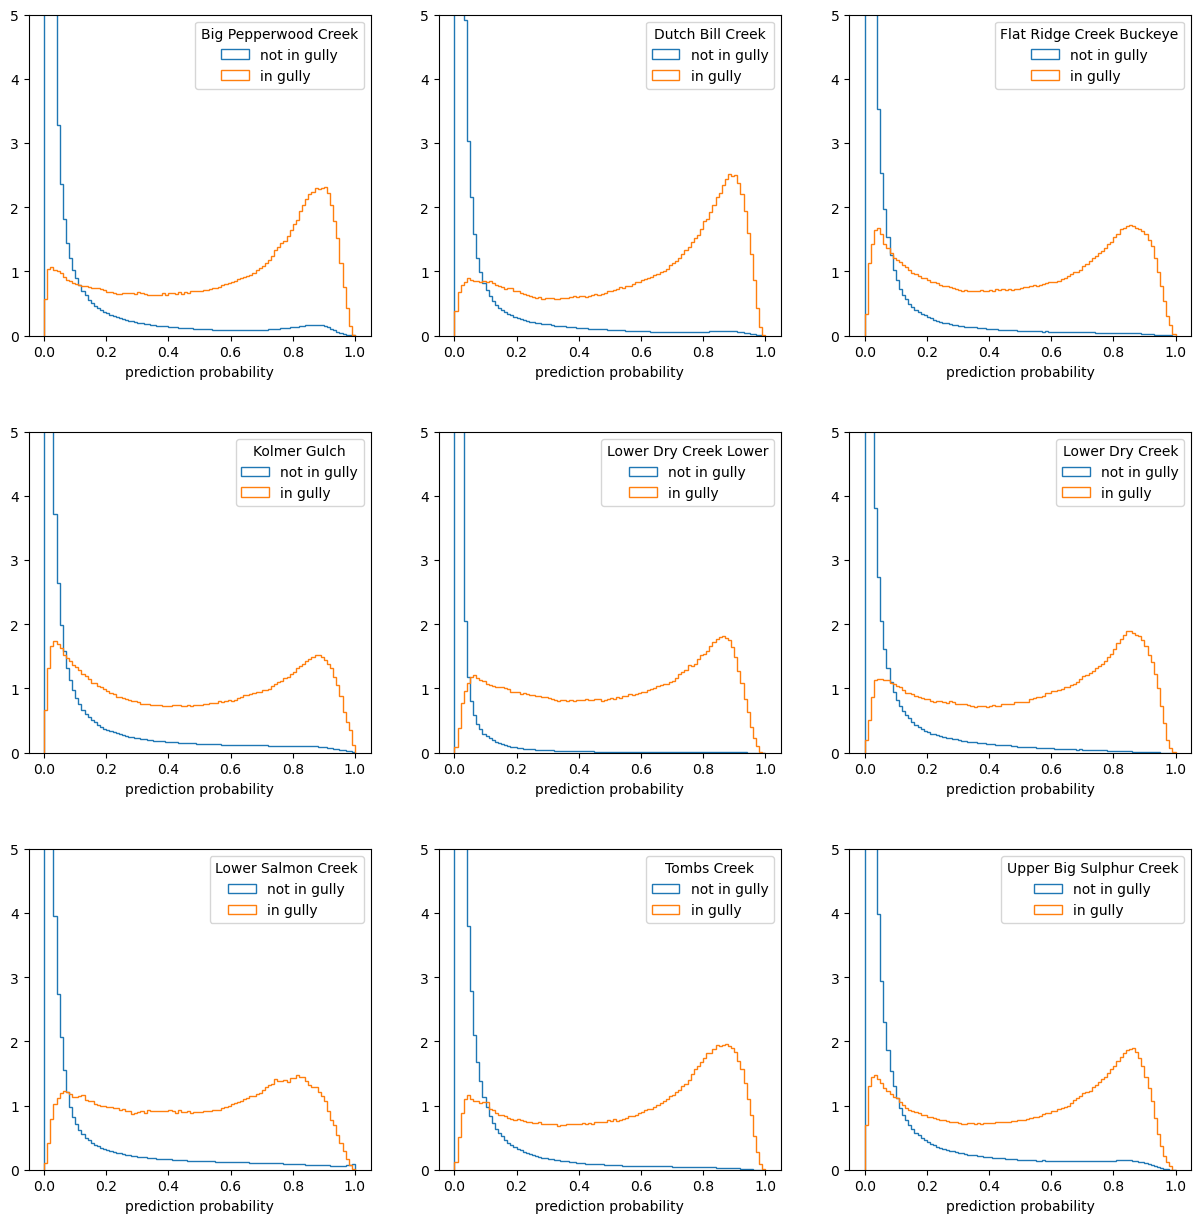

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for ax, name, slc in zip(axs.flatten(), names, slices):
    ax.hist(fit.predict(sm.add_constant(X)[slc][~Y[slc]]), bins=100, range=(0, 1), density=True, histtype="step", label="not in gully")
    ax.hist(fit.predict(sm.add_constant(X)[slc][Y[slc]]), bins=100, range=(0, 1), density=True, histtype="step", label="in gully")

    ax.legend(loc="upper right", title=names[name])

    ax.set_ylim(0, 5)
    ax.set_xlabel("prediction probability")

plt.subplots_adjust(hspace=0.3)

None

In [ ]:
name = "dutch"

with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
    mask = np.asarray(file)[:, :, 1] < 128

with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
    gully = (np.asarray(file)[:, :, 1] > 128).astype(np.float32)

gully[~mask] = np.nan

metrics = {
    "min15": None,
    "max15": None,
    "low15": None,
    "highlow15": None,
    "min5": None,
    "max5": None,
    "low5": None,
    "highlow5": None,
}
for metric in metrics:
    with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
        data = file.read(1)
    np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
    metrics[metric]= data

In [20]:
X_test = np.stack([
    metrics["min15"],
    metrics["max15"],
    metrics["low15"],
    metrics["highlow15"],
    metrics["min5"],
    metrics["max5"],
    metrics["low5"],
    metrics["highlow5"],
    metrics["low15"] * metrics["highlow15"],
    metrics["low15"] * metrics["highlow5"],
    metrics["low5"] * metrics["highlow15"],
    metrics["low5"] * metrics["highlow5"],
]).transpose(1, 2, 0)

assert not np.isnan(X_test[mask]).any()
X_test[np.isnan(X_test)] = 0

In [22]:
probability = fit.predict(sm.add_constant(X_test.reshape(-1, len(features)))).reshape(mask.shape)
probability[~mask] = np.nan

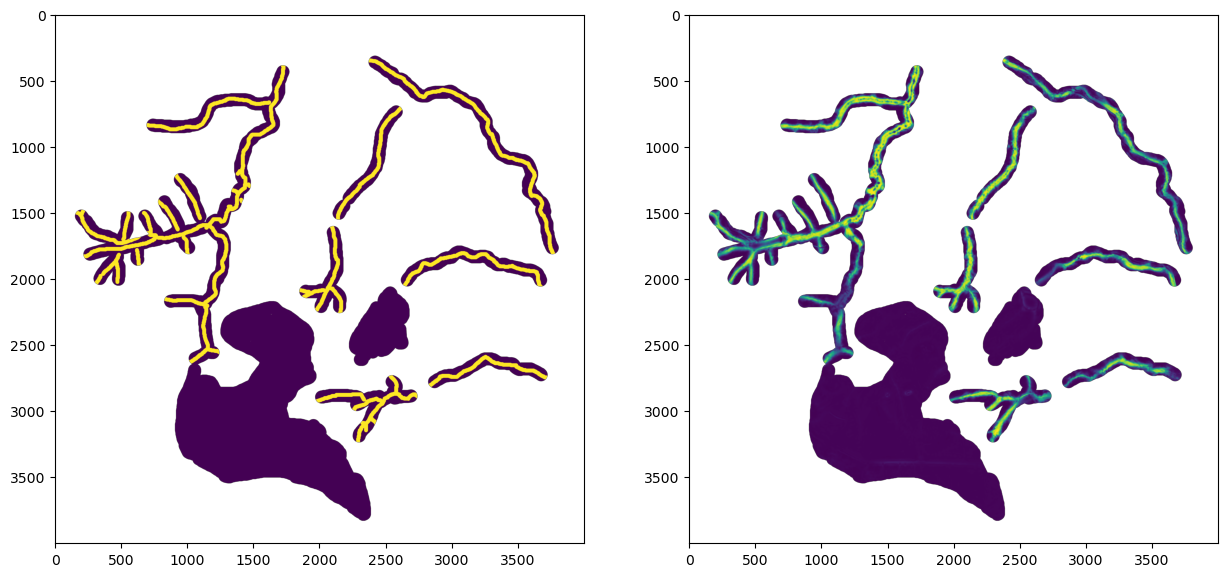

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

ax1.imshow(gully[15000:19000, 14000:18000])
ax2.imshow(probability[15000:19000, 14000:18000])

None